In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

In [3]:
# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)

In [5]:

# Scale the features for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Perform hierarchical clustering using different linkage methods
linkage_ward = linkage(X_scaled, method='ward')
linkage_complete = linkage(X_scaled, method='complete')
linkage_average = linkage(X_scaled, method='average')

In [7]:
def plot_dendrogram(linkage_matrix, method_name):
    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=y, leaf_rotation=90)
    plt.title(f"Dendrogram ({method_name} Linkage)")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

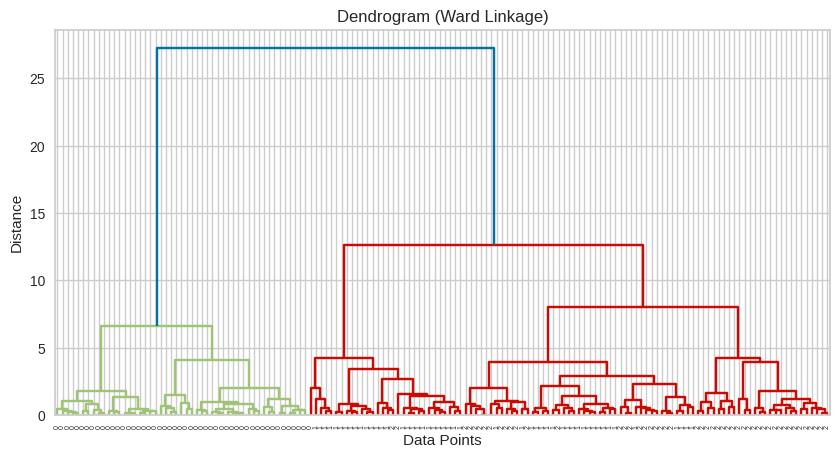

In [8]:
# Plot dendrograms for different linkage methods
plot_dendrogram(linkage_ward, "Ward")

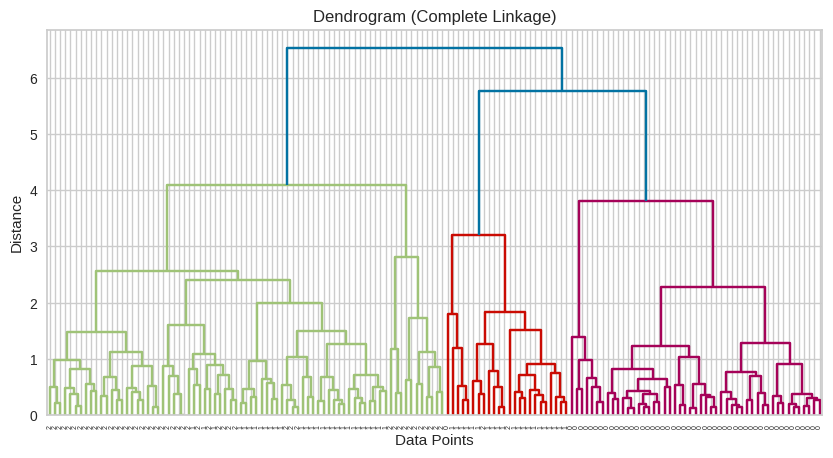

In [9]:
plot_dendrogram(linkage_complete, "Complete")

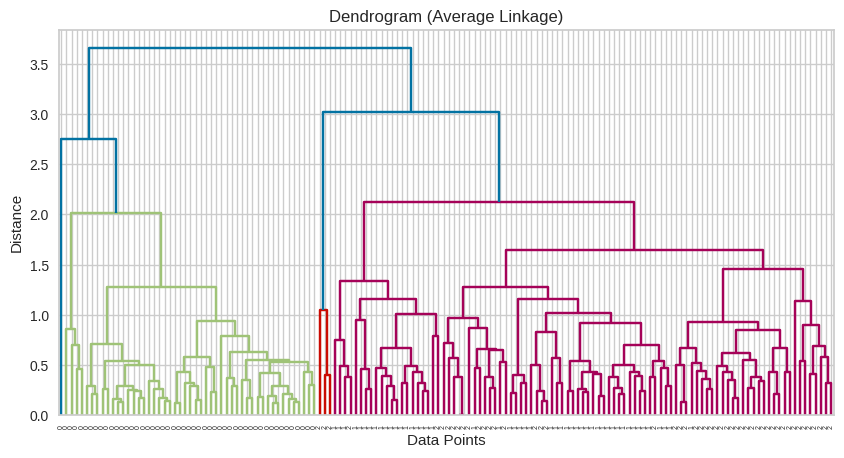

In [10]:
plot_dendrogram(linkage_average, "Average")

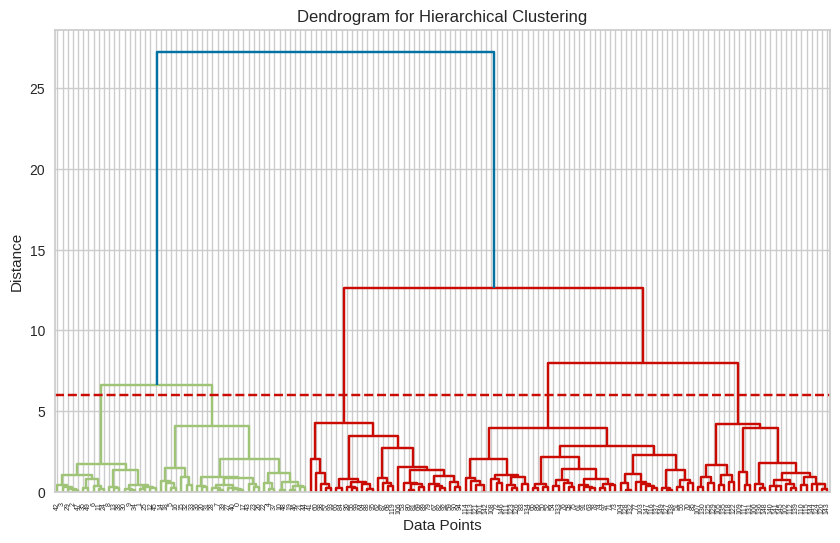

In [11]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load dataset and preprocess
iris = load_iris()
X = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(linkage_matrix)
plt.axhline(y=6, color='r', linestyle='--')  # Manually choose a height based on the largest gap
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


```If the red cut-off line crosses 3 vertical lines, choose k = 3.```

```If it crosses 5 vertical lines, choose k = 5.```

If you want fewer clusters, increase t.

If you want more clusters, decrease t.

The red dashed line in your dendrogram represents the cutoff. Move it up or down to change the number of clusters.

In [12]:
from scipy.cluster.hierarchy import fcluster

# Select number of clusters automatically using inconsistency method
num_clusters = fcluster(linkage_matrix, t=6, criterion='distance')  # Change t based on dendrogram
print(f"Optimal Number of Clusters: {len(set(num_clusters))}")


Optimal Number of Clusters: 5


In [13]:
desired_num_clusters = len(set(num_clusters))

labels_ward = fcluster(linkage_ward, desired_num_clusters, criterion='maxclust')
labels_complete = fcluster(linkage_complete, desired_num_clusters, criterion='maxclust')
labels_average = fcluster(linkage_average, desired_num_clusters, criterion='maxclust')

In [14]:
# Evaluate clustering using Silhouette Score
silhouette_ward = silhouette_score(X_scaled, labels_ward)
silhouette_complete = silhouette_score(X_scaled, labels_complete)
silhouette_average = silhouette_score(X_scaled, labels_average)

In [15]:

print(f"Silhouette Score (Ward Linkage): {silhouette_ward:.2f}")
print(f"Silhouette Score (Complete Linkage): {silhouette_complete:.2f}")
print(f"Silhouette Score (Average Linkage): {silhouette_average:.2f}")


Silhouette Score (Ward Linkage): 0.33
Silhouette Score (Complete Linkage): 0.35
Silhouette Score (Average Linkage): 0.37


In [16]:
# Function to visualize clusters
def plot_clusters(X_scaled, labels, title):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1 (Standardized)")
    plt.ylabel("Feature 2 (Standardized)")
    plt.legend(title="Cluster")
    plt.show()


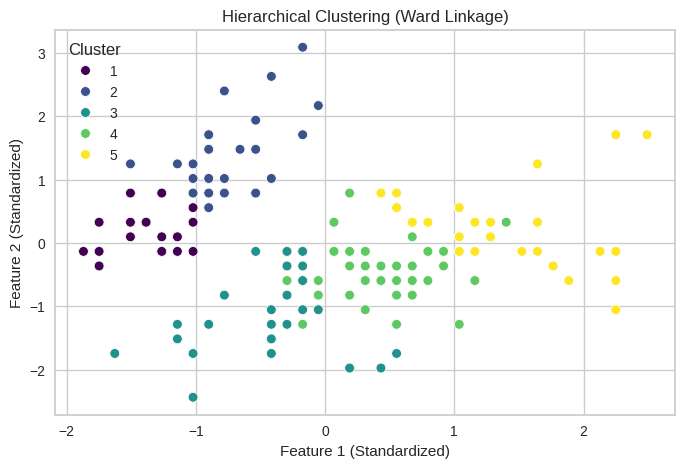

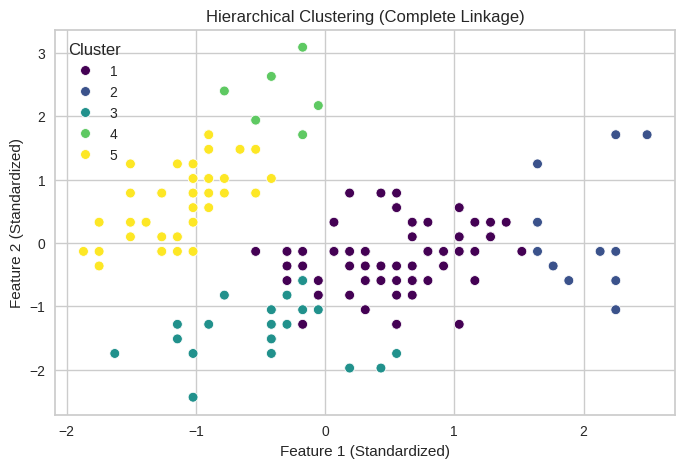

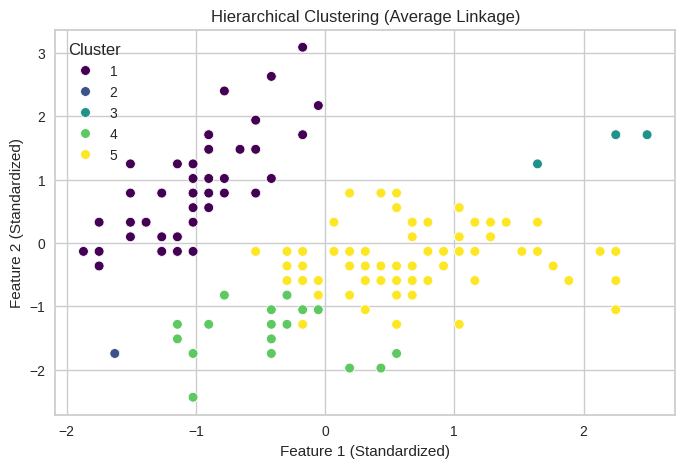

In [17]:
# Plot clusters for different linkage methods
plot_clusters(X_scaled, labels_ward, "Hierarchical Clustering (Ward Linkage)")
plot_clusters(X_scaled, labels_complete, "Hierarchical Clustering (Complete Linkage)")
plot_clusters(X_scaled, labels_average, "Hierarchical Clustering (Average Linkage)")


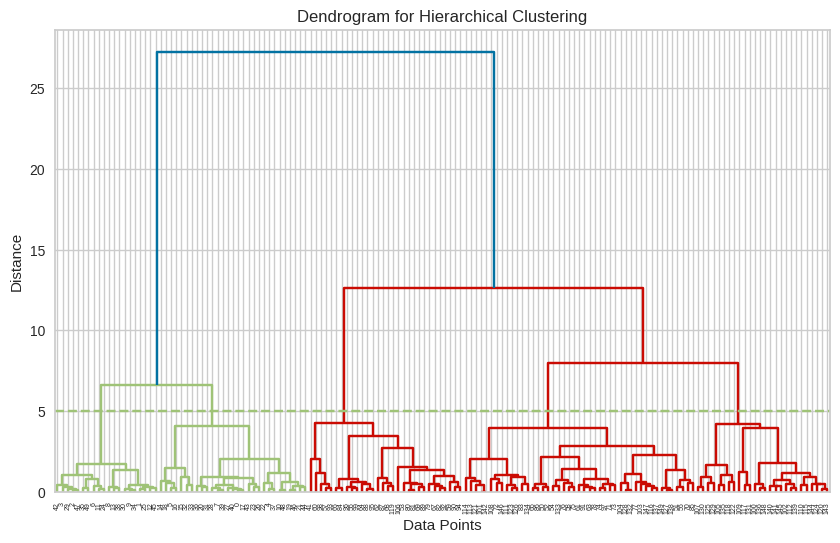

In [18]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

# Add a horizontal cut-off line to determine clusters
plt.axhline(y=5, color='g', linestyle='--')  # Adjust 'y' based on visual analysis
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Dendrogram for Hierarchical Clustering")
plt.show()
